In [ ]:
import mip
from pathlib import Path

PROJECT_ROOT = Path(mip.__file__).parent.parent


In [6]:
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import statistics
from sklearn.cluster import DBSCAN, KMeans


In [7]:
import os
import osmnx as ox

GRAPH_PATH = PROJECT_ROOT / "cache/ukraine_major_roads.graphml"
os.makedirs("cache", exist_ok=True)
ox.settings.max_query_area_size = 50_000_000_000

if os.path.exists(GRAPH_PATH):
    print("Loading cached graph...")
    G_raw = ox.load_graphml(GRAPH_PATH)
else:
    print("Downloading graph...")
    G_raw = ox.graph_from_place(
        "Ukraine",
        network_type="drive",
        custom_filter='["highway"~"motorway|trunk|primary|secondary"]',
    )
    G_raw = ox.add_edge_speeds(G_raw)
    G_raw = ox.add_edge_travel_times(G_raw)
    ox.save_graphml(G_raw, GRAPH_PATH)


Loading cached graph...


Using G_raw as the adaptive-coarsening base graph.
Adaptive coarsening parameters:
  eps_near = 0.15
  eps_mid = 0.25
  eps_far = 0.4
  near_radius = 0.5
  mid_radius = 1.5

Raw-node zone counts:
  near: 3728 raw nodes
  mid: 7808 raw nodes
  far: 13512 raw nodes

Adaptive coarse-node zone counts:
  near: 71 coarse nodes
  mid: 61 coarse nodes
  far: 9 coarse nodes
Adaptive coarsening: 141 nodes, 255 edges
Abstracted path counts per coarse edge: min=1, mean=3.55, max=78

Top coarse edges by abstracted path count:
  Edge (125, 133): paths=78, travel_time=0.00 hr
  Edge (91, 133): paths=26, travel_time=0.09 hr
  Edge (28, 96): paths=16, travel_time=0.01 hr
  Edge (81, 133): paths=14, travel_time=0.00 hr
  Edge (77, 133): paths=12, travel_time=0.04 hr
  Edge (81, 99): paths=12, travel_time=0.33 hr
  Edge (81, 102): paths=12, travel_time=0.37 hr
  Edge (126, 133): paths=12, travel_time=0.23 hr


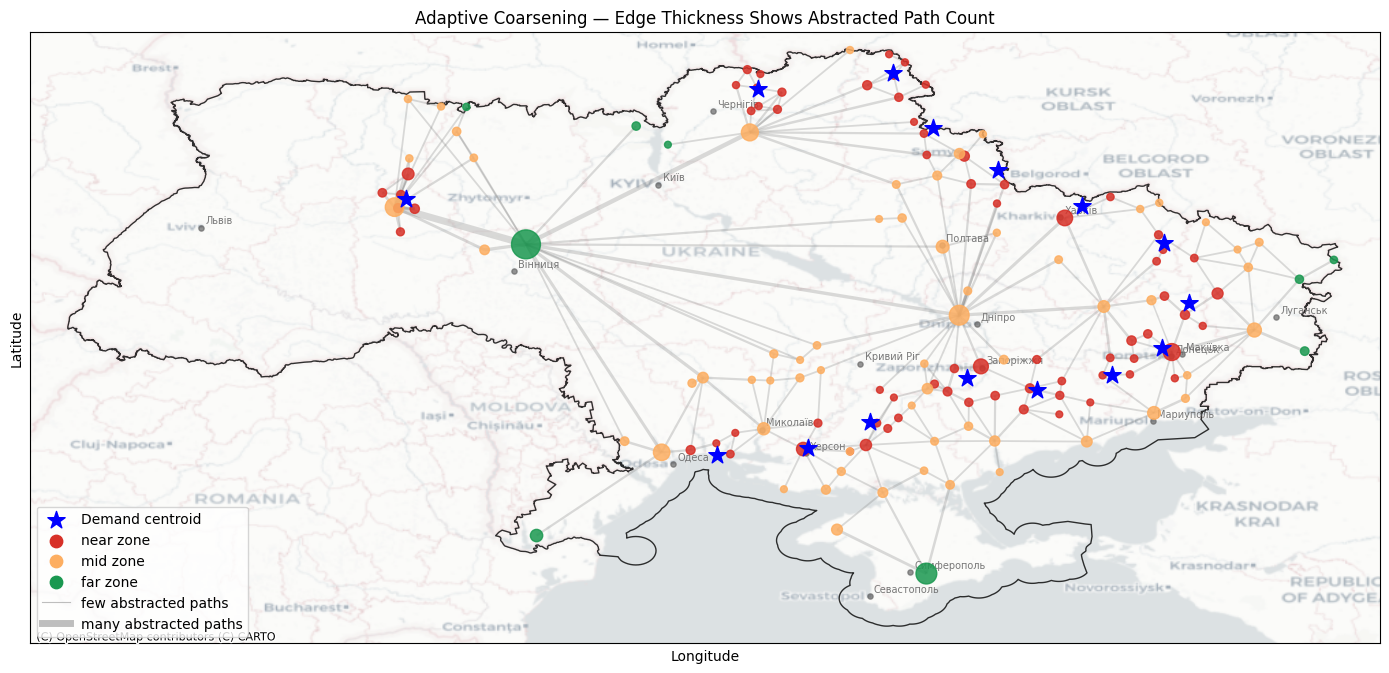

In [8]:
import contextily as ctx
from pathlib import Path
from sklearn.cluster import DBSCAN

def cluster_demand_kmedoids(coords, n_clusters, random_state=42, max_iter=8, candidate_cap=200):
    coords = np.asarray(coords, dtype=float)
    n_samples = len(coords)
    if n_samples == 0:
        raise ValueError("cluster_demand_kmedoids needs at least one point")
    if n_clusters > n_samples:
        raise ValueError("n_clusters cannot exceed the number of points")

    rng = np.random.default_rng(random_state)
    medoid_indices = [int(rng.integers(n_samples))]
    closest_dist = ((coords - coords[medoid_indices[0]]) ** 2).sum(axis=1)

    for _ in range(1, n_clusters):
        total = closest_dist.sum()
        if total <= 0:
            remaining = np.setdiff1d(np.arange(n_samples), np.array(medoid_indices), assume_unique=False)
            next_idx = int(rng.choice(remaining))
        else:
            probs = closest_dist / total
            next_idx = int(rng.choice(n_samples, p=probs))
            while next_idx in medoid_indices:
                next_idx = int(rng.choice(n_samples, p=probs))
        medoid_indices.append(next_idx)
        new_dist = ((coords - coords[next_idx]) ** 2).sum(axis=1)
        closest_dist = np.minimum(closest_dist, new_dist)

    medoid_indices = np.array(medoid_indices, dtype=int)

    for _ in range(max_iter):
        medoids = coords[medoid_indices]
        dist_to_medoids = ((coords[:, None, :] - medoids[None, :, :]) ** 2).sum(axis=2)
        labels = dist_to_medoids.argmin(axis=1)
        updated = medoid_indices.copy()

        for k in range(n_clusters):
            cluster_idx = np.where(labels == k)[0]
            if len(cluster_idx) == 0:
                fallback = int(np.argmax(np.min(dist_to_medoids, axis=1)))
                updated[k] = fallback
                continue

            cluster_points = coords[cluster_idx]
            if len(cluster_idx) > candidate_cap:
                centroid = cluster_points.mean(axis=0)
                order = np.argsort(((cluster_points - centroid) ** 2).sum(axis=1))
                near_count = min(candidate_cap // 2, len(cluster_idx))
                chosen_local = order[:near_count]
                remaining = np.setdiff1d(np.arange(len(cluster_idx)), chosen_local, assume_unique=False)
                extra_count = min(candidate_cap - len(chosen_local), len(remaining))
                if extra_count > 0:
                    extra_local = rng.choice(remaining, size=extra_count, replace=False)
                    chosen_local = np.unique(np.concatenate([chosen_local, extra_local]))
                candidate_idx = cluster_idx[chosen_local]
            else:
                candidate_idx = cluster_idx

            candidate_points = coords[candidate_idx]
            candidate_costs = ((cluster_points[:, None, :] - candidate_points[None, :, :]) ** 2).sum(axis=2).sum(axis=0)
            updated[k] = int(candidate_idx[int(np.argmin(candidate_costs))])

        if np.array_equal(updated, medoid_indices):
            break
        medoid_indices = updated

    final_medoids = coords[medoid_indices]
    final_dist = ((coords[:, None, :] - final_medoids[None, :, :]) ** 2).sum(axis=2)
    labels = final_dist.argmin(axis=1)
    return labels, medoid_indices

def build_demand_nodes_kmedoids(df, n_clusters, random_state=42, candidate_cap=200):
    working = df.copy()
    coords = working[["latitude", "longitude"]].to_numpy(dtype=float)
    labels, medoid_indices = cluster_demand_kmedoids(
        coords,
        n_clusters=n_clusters,
        random_state=random_state,
        candidate_cap=candidate_cap,
    )
    working["cluster"] = labels

    medoid_lookup = {
        cluster_id: {
            "lat": float(coords[medoid_indices[cluster_id], 0]),
            "lon": float(coords[medoid_indices[cluster_id], 1]),
        }
        for cluster_id in range(n_clusters)
    }

    demand_raw = (
        working.groupby("cluster")
        .agg(
            n_events=("event_type", "count"),
            total_fatalities=("fatalities", "sum"),
        )
        .reset_index()
    )
    demand_raw["lat"] = demand_raw["cluster"].map(lambda c: medoid_lookup[c]["lat"])
    demand_raw["lon"] = demand_raw["cluster"].map(lambda c: medoid_lookup[c]["lon"])
    demand_raw = demand_raw[["lat", "lon", "n_events", "total_fatalities"]].reset_index(drop=True)
    return working, demand_raw, medoid_indices

# ── Adaptive coarsening: finer near demand, coarser farther away ─────────
# This uses geographic distance to the demand centroids already built in the
# notebook. A network-travel-time version is also possible, but this is a
# clean first adaptive version that plugs into the current workflow.

if "demand_raw" not in globals():
    print("demand_raw not found; rebuilding demand nodes from ACLED using adaptive-cell k-medoids logic...")
    acled_path = PROJECT_ROOT / "data/ACLED Data_2026-03-25.csv"
    if not acled_path.exists():
        raise FileNotFoundError(f"Could not find ACLED data at {acled_path}")

    acled_df = pd.read_csv(acled_path)
    acled_df = acled_df[
        (acled_df["country"] == "Ukraine")
        & (acled_df["year"] >= 2022)
        & (acled_df["event_type"].isin([
            "Explosions/Remote violence",
            "Battles",
            "Violence against civilians",
        ]))
    ].copy()

    n_demand = globals().get("N_DEMAND", 15)
    acled_df, demand_raw, demand_medoid_indices = build_demand_nodes_kmedoids(
        acled_df,
        n_clusters=n_demand,
        random_state=42,
        candidate_cap=200,
    )
    print(f"Rebuilt demand_raw with {len(demand_raw)} demand nodes (k-medoids, k={n_demand}).")

def adaptive_coarsen_graph(
    G,
    demand_points,
    eps_near=0.12,
    eps_mid=0.22,
    eps_far=0.40,
    near_radius=0.18,
    mid_radius=0.55,
):
    if hasattr(demand_points, "loc"):
        demand_coords = demand_points[["lat", "lon"]].to_numpy(dtype=float)
    else:
        demand_coords = np.asarray(demand_points, dtype=float)

    if len(demand_coords) == 0:
        raise ValueError("adaptive_coarsen_graph needs at least one demand point")

    node_ids = list(G.nodes())
    coords = np.array([[G.nodes[n]["y"], G.nodes[n]["x"]] for n in node_ids], dtype=float)

    node_to_demand_dist = {}
    zone_to_nodes = {"near": [], "mid": [], "far": []}
    for i, n in enumerate(node_ids):
        dist = np.sqrt(((demand_coords - coords[i]) ** 2).sum(axis=1)).min()
        node_to_demand_dist[n] = float(dist)
        if dist <= near_radius:
            zone_to_nodes["near"].append(n)
        elif dist <= mid_radius:
            zone_to_nodes["mid"].append(n)
        else:
            zone_to_nodes["far"].append(n)

    zone_eps = {"near": eps_near, "mid": eps_mid, "far": eps_far}
    node_to_cluster = {}
    cluster_info = {}
    cluster_id = 0

    for zone in ["near", "mid", "far"]:
        zone_nodes = zone_to_nodes[zone]
        if not zone_nodes:
            continue

        zone_coords = np.array([[G.nodes[n]["y"], G.nodes[n]["x"]] for n in zone_nodes], dtype=float)
        labels = DBSCAN(eps=zone_eps[zone], min_samples=1).fit(zone_coords).labels_

        for label in sorted(set(labels)):
            members = [zone_nodes[i] for i, lab in enumerate(labels) if lab == label]
            cid = cluster_id
            cluster_id += 1

            for n in members:
                node_to_cluster[n] = cid

            cluster_info[cid] = {
                "zone": zone,
                "lat": float(np.mean([G.nodes[n]["y"] for n in members])),
                "lon": float(np.mean([G.nodes[n]["x"] for n in members])),
                "member_count": len(members),
                "mean_demand_dist": float(np.mean([node_to_demand_dist[n] for n in members])),
                "territory_occupation_fraction": float(np.mean([G.nodes[n].get("territory_occupation_fraction", 0.0) for n in members])),
                "territory_border_risk": float(max([G.nodes[n].get("territory_border_risk", 0.0) for n in members])),
                "territory_border_distance_km": float(min([G.nodes[n].get("territory_border_distance_km", float("inf")) for n in members])),
                "territory_interior_depth_km": float(max([G.nodes[n].get("territory_interior_depth_km", 0.0) for n in members])),
            }

    CG_adaptive = nx.Graph()
    for cid, attrs in cluster_info.items():
        CG_adaptive.add_node(cid, **attrs)

    for u, v, data in G.edges(data=True):
        cu, cv = node_to_cluster[u], node_to_cluster[v]
        if cu == cv:
            continue
        t = data.get("travel_time", float("inf"))
        if CG_adaptive.has_edge(cu, cv):
            CG_adaptive[cu][cv]["abstracted_path_count"] += 1
            if t < CG_adaptive[cu][cv]["travel_time"]:
                CG_adaptive[cu][cv]["travel_time"] = t
        else:
            CG_adaptive.add_edge(
                cu,
                cv,
                travel_time=t,
                abstracted_path_count=1,
            )

    CG_adaptive = CG_adaptive.subgraph(max(nx.connected_components(CG_adaptive), key=len)).copy()
    return CG_adaptive, node_to_demand_dist, zone_to_nodes

# Example configuration for the country-wide graph.
# Smaller eps near demand keeps more detail around important areas.
adaptive_params = {
    "eps_near": 0.15,
    "eps_mid": 0.25,
    "eps_far": 0.4,
    "near_radius": 0.5,
    "mid_radius": 1.5,
}

if "G_raw_current_filtered" in globals():
    adaptive_base_graph = G_raw_current_filtered
    adaptive_base_name = "G_raw_current_filtered"
elif "G_raw_temporal_filtered" in globals():
    adaptive_base_graph = G_raw_temporal_filtered
    adaptive_base_name = "G_raw_temporal_filtered"
elif "G_raw_unoccupied" in globals():
    adaptive_base_graph = G_raw_unoccupied
    adaptive_base_name = "G_raw_unoccupied"
else:
    adaptive_base_graph = G_raw
    adaptive_base_name = "G_raw"
print(f"Using {adaptive_base_name} as the adaptive-coarsening base graph.")

CG_adaptive, raw_dist_to_demand, raw_zone_membership = adaptive_coarsen_graph(
    adaptive_base_graph,
    demand_raw[["lat", "lon"]],
    **adaptive_params,
)

print("Adaptive coarsening parameters:")
for k, v in adaptive_params.items():
    print(f"  {k} = {v}")

print("\nRaw-node zone counts:")
for zone in ["near", "mid", "far"]:
    print(f"  {zone}: {len(raw_zone_membership[zone])} raw nodes")

adaptive_zone_counts = pd.Series([CG_adaptive.nodes[n]["zone"] for n in CG_adaptive.nodes()]).value_counts()
print("\nAdaptive coarse-node zone counts:")
for zone in ["near", "mid", "far"]:
    print(f"  {zone}: {int(adaptive_zone_counts.get(zone, 0))} coarse nodes")

# print(f"\nUniform coarsening:  {CG.number_of_nodes()} nodes, {CG.number_of_edges()} edges")
print(f"Adaptive coarsening: {CG_adaptive.number_of_nodes()} nodes, {CG_adaptive.number_of_edges()} edges")

edge_path_counts = [d["abstracted_path_count"] for _, _, d in CG_adaptive.edges(data=True)]
print(
    f"Abstracted path counts per coarse edge: min={min(edge_path_counts)}, "
    f"mean={np.mean(edge_path_counts):.2f}, max={max(edge_path_counts)}"
)

top_supported_edges = sorted(
    CG_adaptive.edges(data=True),
    key=lambda e: e[2]["abstracted_path_count"],
    reverse=True,
)[:8]
print("\nTop coarse edges by abstracted path count:")
for u, v, data in top_supported_edges:
    print(
        f"  Edge ({u}, {v}): paths={data['abstracted_path_count']}, "
        f"travel_time={data['travel_time'] / 3600:.2f} hr"
    )

# Quick visual check: near-demand areas should keep more coarse nodes.
if "ukraine_shape" not in globals():
    ukraine_shape = ox.geocode_to_gdf("Ukraine")
if "cities" not in globals():
    cities = ox.features_from_place("Ukraine", tags={"place": ["city"]}).copy()
    cities = cities[cities.geometry.geom_type == "Point"].copy()
    cities = cities[cities["name"].notna()].copy()
    if "population" in cities.columns:
        cities["population_num"] = pd.to_numeric(cities["population"], errors="coerce")
    else:
        cities["population_num"] = np.nan
    cities = cities.sort_values(["population_num", "name"], ascending=[False, True])
    cities = cities.drop_duplicates(subset="name").head(18)

zone_colors = {"near": "#d73027", "mid": "#fdae61", "far": "#1a9850"}
adaptive_pos = {n: (d["lon"], d["lat"]) for n, d in CG_adaptive.nodes(data=True)}
minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(minx - x_pad, maxx + x_pad)
ax.set_ylim(miny - y_pad, maxy + y_pad)
try:
    ctx.add_basemap(
        ax,
        crs="EPSG:4326",
        source=ctx.providers.CartoDB.Positron,
        zoom=6,
        alpha=0.8,
    )
except Exception as exc:
    print(f"Basemap unavailable for adaptive plot, continuing without tiles: {exc}")

ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.8, zorder=1)
cities.plot(ax=ax, color="dimgray", markersize=14, alpha=0.7, zorder=2)
for _, city in cities.iterrows():
    ax.annotate(
        city["name"],
        (city.geometry.x, city.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=7,
        color="dimgray",
        alpha=0.9,
        zorder=3,
    )

edge_list = list(CG_adaptive.edges(data=True))
edge_widths = [
    0.6 + 4.4 * np.sqrt(edge_data["abstracted_path_count"]) / np.sqrt(max(edge_path_counts))
    for _, _, edge_data in edge_list
]
edge_collection = nx.draw_networkx_edges(
    CG_adaptive,
    adaptive_pos,
    ax=ax,
    edgelist=[(u, v) for u, v, _ in edge_list],
    alpha=0.28,
    edge_color="gray",
    width=edge_widths,
)
edge_collection.set_zorder(4)

adaptive_sizes = [20 + 4 * np.sqrt(CG_adaptive.nodes[n]["member_count"]) for n in CG_adaptive.nodes()]
adaptive_colors = [zone_colors[CG_adaptive.nodes[n]["zone"]] for n in CG_adaptive.nodes()]
node_collection = nx.draw_networkx_nodes(
    CG_adaptive,
    adaptive_pos,
    ax=ax,
    node_size=adaptive_sizes,
    node_color=adaptive_colors,
    alpha=0.85,
)
node_collection.set_zorder(5)

demand_x = [row["lon"] for _, row in demand_raw.iterrows()]
demand_y = [row["lat"] for _, row in demand_raw.iterrows()]
ax.scatter(demand_x, demand_y, marker="*", c="blue", s=170, zorder=6, label="Demand centroid")

for zone in ["near", "mid", "far"]:
    ax.scatter([], [], c=zone_colors[zone], s=80, label=f"{zone} zone")
ax.plot([], [], color="gray", linewidth=0.8, alpha=0.5, label="few abstracted paths")
ax.plot([], [], color="gray", linewidth=5.0, alpha=0.5, label="many abstracted paths")

ax.set_title("Adaptive Coarsening — Edge Thickness Shows Abstracted Path Count")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/adaptive_coarsening.png", dpi=150, bbox_inches="tight")
plt.show()

# If you want to use the adaptive graph downstream, uncomment the next line.
# CG = CG_adaptive


Computing betweenness centrality on CG_adaptive (may take a moment)...

aᵢ: min=4.42, mean=9.91, max=10.00
bᵢ: min=4.10, mean=9.91, max=10.00
Large hub threshold (member_count): 28.00
Large hub nodes: [0, 2, 4, 16, 28, 31, 36, 38, 52, 56, 59, 62, 66, 67, 70, 71, 72, 73, 76, 77, 81, 82, 91, 96, 98, 99, 106, 108, 112, 114, 120, 123, 125, 126, 132, 133, 137]
Territory border risk: min=0.000, mean=0.000, max=0.000
Territory threat: min=0.325, mean=0.325, max=0.325
Occupied share: min=0.000, mean=0.000, max=0.000
Incident edge support: min=2, mean=12.84, max=180

Top 5 cheapest nodes to open (lowest aᵢ):
  Node 133: aᵢ=4.422, bᵢ=4.1, lat=49.606, lon=28.644, degree=16, centrality=0.644, members=10645, large_hub_proximity=0.344, edge_support=180, territory_risk=0.000, occupied_share=0.000, territory_threat=0.325
  Node 81: aᵢ=6.025, bᵢ=6.822, lat=48.600, lon=34.796, degree=21, centrality=0.606, members=2073, large_hub_proximity=0.556, edge_support=112, territory_risk=0.000, occupied_share=0.0

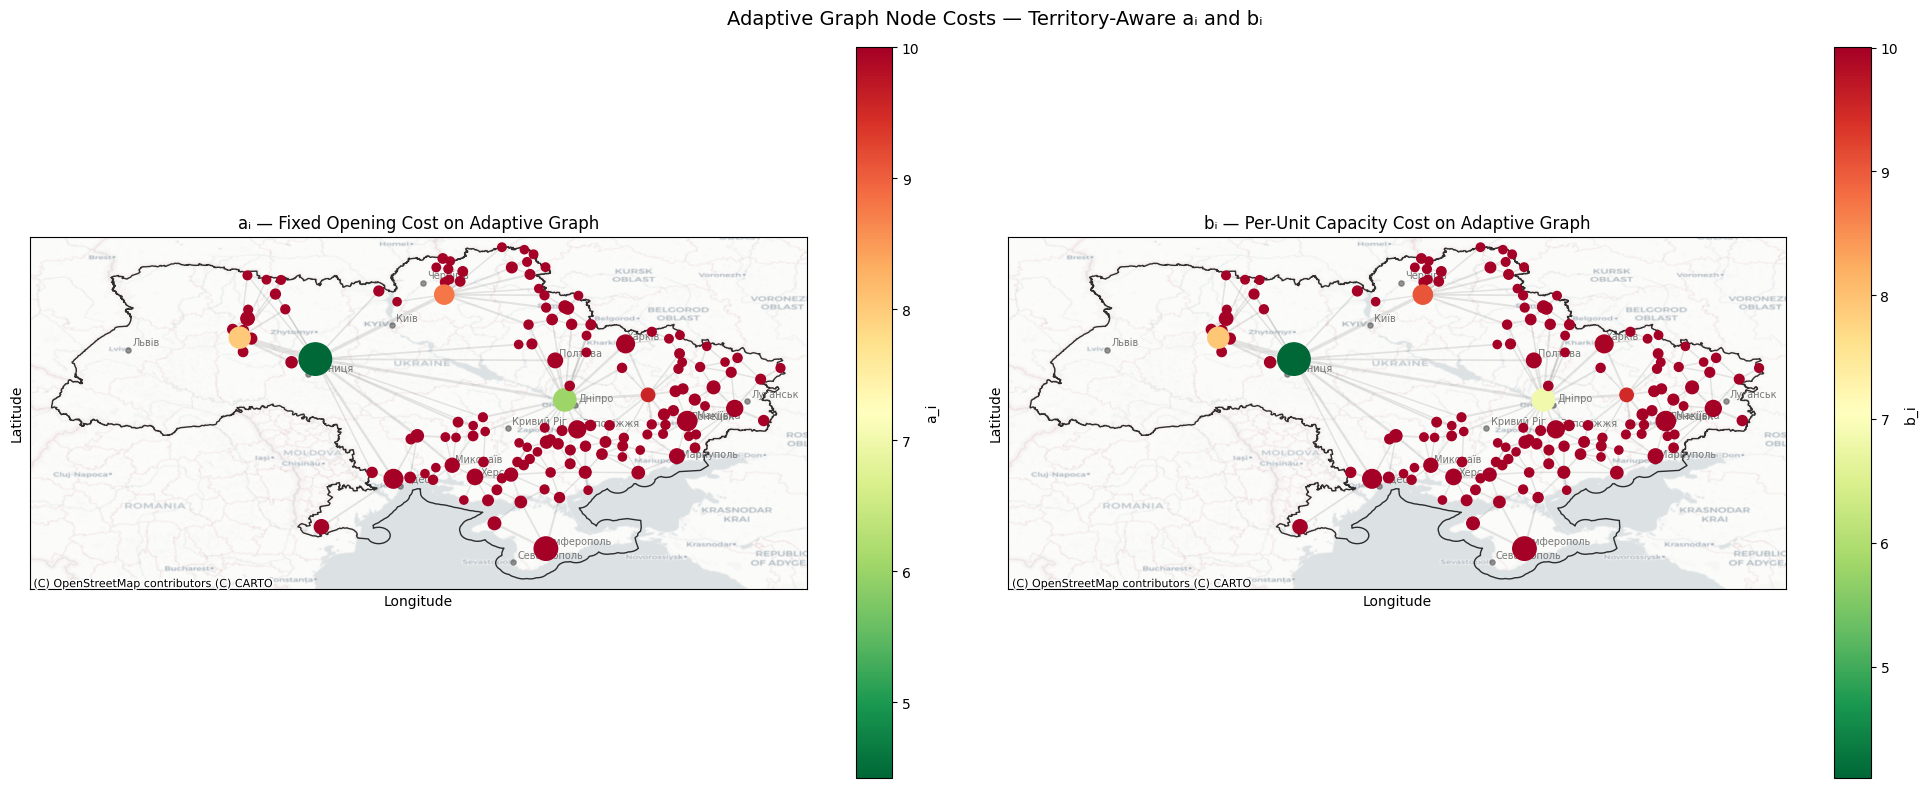

In [9]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import contextily as ctx

# ── Compute node features on the adaptive coarse graph ───────────────────
degree = dict(CG_adaptive.degree())

print("Computing betweenness centrality on CG_adaptive (may take a moment)...")
centrality = nx.betweenness_centrality(CG_adaptive, weight="travel_time", normalized=True)

member_count = {n: CG_adaptive.nodes[n].get("member_count", 1) for n in CG_adaptive.nodes()}
territory_border_risk = {n: CG_adaptive.nodes[n].get("territory_border_risk", 0.0) for n in CG_adaptive.nodes()}
territory_occupation_fraction = {n: CG_adaptive.nodes[n].get("territory_occupation_fraction", 0.0) for n in CG_adaptive.nodes()}
territory_border_distance_km = {n: CG_adaptive.nodes[n].get("territory_border_distance_km", np.inf) for n in CG_adaptive.nodes()}
territory_interior_depth_km = {n: CG_adaptive.nodes[n].get("territory_interior_depth_km", 0.0) for n in CG_adaptive.nodes()}
incident_edge_support = {
    n: sum(data.get("abstracted_path_count", 1) for _, _, data in CG_adaptive.edges(n, data=True))
    for n in CG_adaptive.nodes()
}

# Large-hub proximity: cheaper if a node is itself large and near other large hubs.
large_hub_threshold = np.quantile(list(member_count.values()), 0.75)
large_hub_ids = [n for n, m in member_count.items() if m >= large_hub_threshold]
if not large_hub_ids:
    large_hub_ids = list(CG_adaptive.nodes())

def dist_to_large_hub(CG, node, large_hub_ids):
    node_lat = CG.nodes[node]["lat"]
    node_lon = CG.nodes[node]["lon"]
    dists = []
    for h in large_hub_ids:
        if h == node:
            continue
        h_lat = CG.nodes[h]["lat"]
        h_lon = CG.nodes[h]["lon"]
        base_dist = ((node_lat - h_lat)**2 + (node_lon - h_lon)**2)**0.5
        hub_scale = np.sqrt(CG.nodes[h].get("member_count", 1))
        dists.append(base_dist / hub_scale)
    if not dists:
        return 0.0
    return min(dists)

large_hub_dist = {n: dist_to_large_hub(CG_adaptive, n, large_hub_ids) for n in CG_adaptive.nodes()}

# ── Normalize to [0, 1] ──────────────────────────────────────────────────
def normalize(d):
    vals = np.array(list(d.values()), dtype=float)
    mn, mx = vals.min(), vals.max()
    if mx == mn:
        return {k: 0.5 for k in d}
    return {k: (float(v) - mn) / (mx - mn) for k, v in d.items()}

norm_degree = normalize(degree)
norm_centrality = normalize(centrality)
norm_member = normalize(member_count)
norm_large_hub_dist = normalize(large_hub_dist)
norm_incident_support = normalize(incident_edge_support)
norm_interior_depth = normalize(territory_interior_depth_km)

large_hub_proximity = {n: 1 - norm_large_hub_dist[n] for n in CG_adaptive.nodes()}
territory_buffer_km = 35.0
border_proximity = {
    n: max(0.0, 1.0 - min(float(territory_border_distance_km[n]), territory_buffer_km) / territory_buffer_km)
    for n in CG_adaptive.nodes()
}
occupied_pressure = {
    n: max(float(territory_occupation_fraction[n]), float(norm_interior_depth[n]))
    for n in CG_adaptive.nodes()
}
territory_threat = {
    n: min(1.0, 0.35 * border_proximity[n] + 0.65 * occupied_pressure[n] + 0.30 * territory_border_risk[n])
    for n in CG_adaptive.nodes()
}

# ── Compute aᵢ and bᵢ ────────────────────────────────────────────────────
# aᵢ = fixed opening cost
#   high if: low degree (isolated, harder to supply)
#   low if:  high member count (existing infrastructure)
#   low if:  close to other larger hubs (supporting infrastructure nearby)
#   low if:  strong abstracted edge support reaches the node
#   high if: close to the occupied/disputed boundary
#   very high if: the node begins to sit inside occupied territory
#
# bᵢ = per-unit capacity cost
#   low if:  high centrality (efficient to expand)
#   low if:  high member count (existing infrastructure)
#   low if:  close to other larger hubs (shared support / redundancy)
#   low if:  strong abstracted edge support reaches the node
#   high if: close to the occupied/disputed boundary
#   very high if: the node begins to sit inside occupied territory
node_params = {}
for n in CG_adaptive.nodes():
    # Border-adjacent nodes remain eligible, but territory exposure drives a heavy surcharge.
    territory_penalty = 1.0 + 2.25 * territory_threat[n]
    a_score = min(1.0, (
        0.20 * (1 - norm_degree[n])
      + 0.12 * (1 - norm_centrality[n])
      + 0.16 * (1 - norm_member[n])
      + 0.10 * (1 - large_hub_proximity[n])
      + 0.10 * (1 - norm_incident_support[n])
      + 0.32 * territory_threat[n]
    ) * territory_penalty)
    b_score = min(1.0, (
        0.18 * (1 - norm_centrality[n])
      + 0.15 * (1 - norm_member[n])
      + 0.12 * (1 - large_hub_proximity[n])
      + 0.18 * (1 - norm_incident_support[n])
      + 0.37 * territory_threat[n]
    ) * territory_penalty)
    node_params[n] = {
        "a_i": round(1 + 9 * a_score, 3),
        "b_i": round(1 + 9 * b_score, 3),
    }

# Save back onto the adaptive graph for downstream optimization work.
nx.set_node_attributes(CG_adaptive, {n: vals["a_i"] for n, vals in node_params.items()}, "a_i")
nx.set_node_attributes(CG_adaptive, {n: vals["b_i"] for n, vals in node_params.items()}, "b_i")
nx.set_node_attributes(CG_adaptive, degree, "degree")
nx.set_node_attributes(CG_adaptive, centrality, "betweenness_centrality")
nx.set_node_attributes(CG_adaptive, member_count, "member_count")
nx.set_node_attributes(CG_adaptive, large_hub_proximity, "large_hub_proximity")
nx.set_node_attributes(CG_adaptive, incident_edge_support, "incident_edge_support")
nx.set_node_attributes(CG_adaptive, territory_border_risk, "territory_border_risk")
nx.set_node_attributes(CG_adaptive, territory_occupation_fraction, "territory_occupation_fraction")
nx.set_node_attributes(CG_adaptive, territory_border_distance_km, "territory_border_distance_km")
nx.set_node_attributes(CG_adaptive, territory_interior_depth_km, "territory_interior_depth_km")
nx.set_node_attributes(CG_adaptive, territory_threat, "territory_threat")

# ── Print summary ─────────────────────────────────────────────────────────
a_vals = [v["a_i"] for v in node_params.values()]
b_vals = [v["b_i"] for v in node_params.values()]
print(f"\naᵢ: min={min(a_vals):.2f}, mean={np.mean(a_vals):.2f}, max={max(a_vals):.2f}")
print(f"bᵢ: min={min(b_vals):.2f}, mean={np.mean(b_vals):.2f}, max={max(b_vals):.2f}")
print(f"Large hub threshold (member_count): {large_hub_threshold:.2f}")
print(f"Large hub nodes: {large_hub_ids}")
print(
    f"Territory border risk: min={min(territory_border_risk.values()):.3f}, "
    f"mean={np.mean(list(territory_border_risk.values())):.3f}, "
    f"max={max(territory_border_risk.values()):.3f}"
)
print(
    f"Territory threat: min={min(territory_threat.values()):.3f}, "
    f"mean={np.mean(list(territory_threat.values())):.3f}, "
    f"max={max(territory_threat.values()):.3f}"
)
print(
    f"Occupied share: min={min(territory_occupation_fraction.values()):.3f}, "
    f"mean={np.mean(list(territory_occupation_fraction.values())):.3f}, "
    f"max={max(territory_occupation_fraction.values()):.3f}"
)
print(
    f"Incident edge support: min={min(incident_edge_support.values())}, "
    f"mean={np.mean(list(incident_edge_support.values())):.2f}, "
    f"max={max(incident_edge_support.values())}"
)

sorted_by_a = sorted(node_params.items(), key=lambda x: x[1]["a_i"])
print("\nTop 5 cheapest nodes to open (lowest aᵢ):")
for n, p in sorted_by_a[:5]:
    print(
        f"  Node {n}: aᵢ={p['a_i']}, bᵢ={p['b_i']}, "
        f"lat={CG_adaptive.nodes[n]['lat']:.3f}, lon={CG_adaptive.nodes[n]['lon']:.3f}, "
        f"degree={degree[n]}, centrality={centrality[n]:.3f}, members={member_count[n]}, "
        f"large_hub_proximity={large_hub_proximity[n]:.3f}, "
        f"edge_support={incident_edge_support[n]}, territory_risk={territory_border_risk[n]:.3f}, "
        f"occupied_share={territory_occupation_fraction[n]:.3f}, territory_threat={territory_threat[n]:.3f}"
    )

# ── Visualize aᵢ and bᵢ on the Ukraine map ───────────────────────────────
if "ukraine_shape" not in globals():
    ukraine_shape = ox.geocode_to_gdf("Ukraine")
if "cities" not in globals():
    cities = ox.features_from_place("Ukraine", tags={"place": ["city"]}).copy()
    cities = cities[cities.geometry.geom_type == "Point"].copy()
    cities = cities[cities["name"].notna()].copy()
    if "population" in cities.columns:
        cities["population_num"] = pd.to_numeric(cities["population"], errors="coerce")
    else:
        cities["population_num"] = np.nan
    cities = cities.sort_values(["population_num", "name"], ascending=[False, True])
    cities = cities.drop_duplicates(subset="name").head(18)

adaptive_pos = {n: (d["lon"], d["lat"]) for n, d in CG_adaptive.nodes(data=True)}
minx, miny, maxx, maxy = ukraine_shape.total_bounds
x_pad = (maxx - minx) * 0.03
y_pad = (maxy - miny) * 0.03
edge_list = list(CG_adaptive.edges(data=True))
edge_path_counts = [d.get("abstracted_path_count", 1) for _, _, d in edge_list]
edge_widths = [
    0.5 + 3.5 * np.sqrt(edge_data.get("abstracted_path_count", 1)) / np.sqrt(max(edge_path_counts))
    for _, _, edge_data in edge_list
]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, cost_key, title in zip(
    axes,
    ["a_i", "b_i"],
    ["aᵢ — Fixed Opening Cost on Adaptive Graph", "bᵢ — Per-Unit Capacity Cost on Adaptive Graph"],
):
    costs = [node_params[n][cost_key] for n in CG_adaptive.nodes()]
    norm = mcolors.Normalize(vmin=min(costs), vmax=max(costs))
    cmap = cm.RdYlGn_r

    ax.set_xlim(minx - x_pad, maxx + x_pad)
    ax.set_ylim(miny - y_pad, maxy + y_pad)
    try:
        ctx.add_basemap(
            ax,
            crs="EPSG:4326",
            source=ctx.providers.CartoDB.Positron,
            zoom=6,
            alpha=0.8,
        )
    except Exception as exc:
        print(f"Basemap unavailable for {cost_key}, continuing without tiles: {exc}")

    ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.8, zorder=1)
    cities.plot(ax=ax, color="dimgray", markersize=14, alpha=0.7, zorder=2)
    for _, city in cities.iterrows():
        ax.annotate(
            city["name"],
            (city.geometry.x, city.geometry.y),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7,
            color="dimgray",
            alpha=0.9,
            zorder=3,
        )

    edge_collection = nx.draw_networkx_edges(
        CG_adaptive,
        adaptive_pos,
        ax=ax,
        edgelist=[(u, v) for u, v, _ in edge_list],
        edge_color="gray",
        alpha=0.20,
        width=edge_widths,
    )
    edge_collection.set_zorder(4)

    node_collection = nx.draw_networkx_nodes(
        CG_adaptive,
        adaptive_pos,
        ax=ax,
        node_color=costs,
        cmap=cmap,
        node_size=[30 + 5 * np.sqrt(member_count[n]) for n in CG_adaptive.nodes()],
        vmin=min(costs),
        vmax=max(costs),
    )
    node_collection.set_zorder(5)

    if "current_occupied_gs" in globals():
        current_occupied_gs.boundary.plot(ax=ax, color="crimson", linewidth=1.2, alpha=0.8, zorder=6)

    high_threat_nodes = [n for n in CG_adaptive.nodes() if territory_threat[n] > 0.55]
    if high_threat_nodes:
        ax.scatter(
            [adaptive_pos[n][0] for n in high_threat_nodes],
            [adaptive_pos[n][1] for n in high_threat_nodes],
            facecolors="none",
            edgecolors="crimson",
            s=[70 + 10 * np.sqrt(member_count[n]) for n in high_threat_nodes],
            linewidths=0.9,
            zorder=7,
            label="High territory threat",
        )

    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=cost_key)
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="lower left")

plt.suptitle("Adaptive Graph Node Costs — Territory-Aware aᵢ and bᵢ", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/adaptive_cost_structure.png", dpi=150, bbox_inches="tight")
plt.show()


Using current occupied-territory snapshot: 2026-03-29
Original base graph:        25048 nodes, 49033 edges
Current-filtered graph:     22007 nodes, 42808 edges
Removed deep occupied nodes: 3033
Border risk: min=0.000, mean=0.215, max=1.000
Occupied interior depth (km): min=0.000, mean=5.691, max=100.074


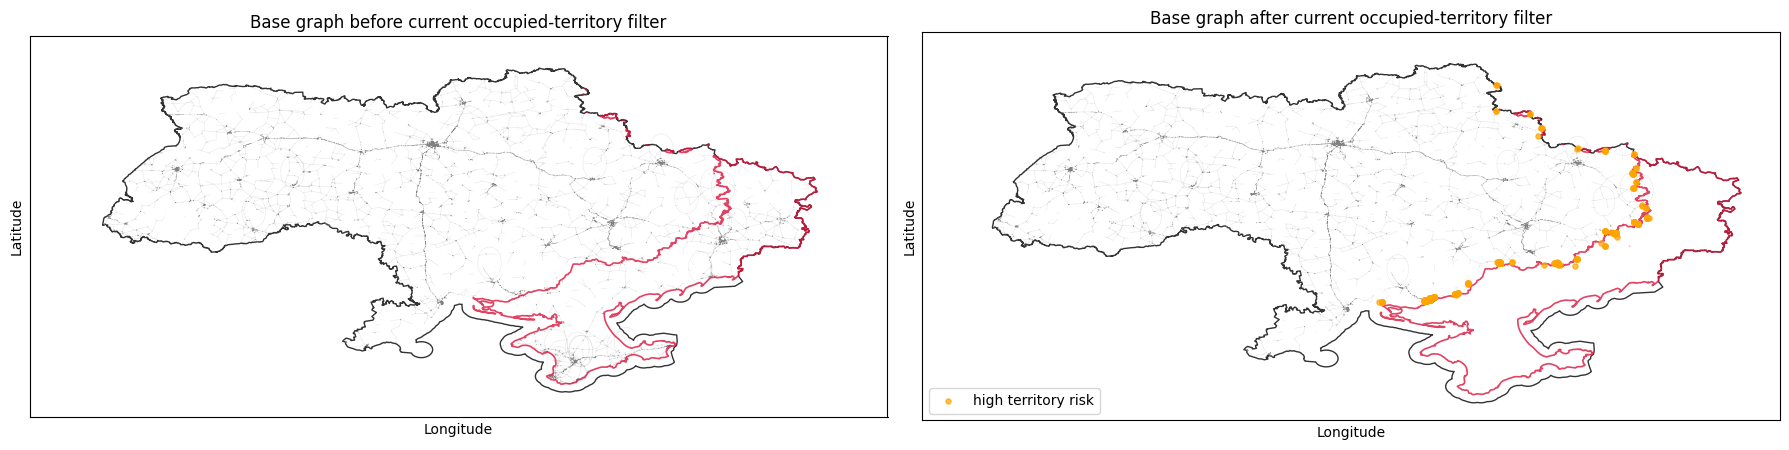

In [10]:
import geopandas as gpd
import gzip
import shutil
from pathlib import Path
from urllib.request import urlopen

# ── Current occupied-territory filter ───────────────────────────────────
# Idea:
# 1. Use the latest occupied/disputed geometry in the cached dataset.
# 2. Remove nodes deep inside occupied territory.
# 3. Keep border-adjacent nodes, but attach a strong territory-risk score
#    that downstream cost logic can penalize heavily.

OCCUPIED_CACHE_GZ = PROJECT_ROOT / "data/deepstate-map-data.geojson.gz"
OCCUPIED_CACHE_GEOJSON = PROJECT_ROOT / "data/deepstate-map-data.geojson"
OCCUPIED_REMOTE_URL = "https://raw.githubusercontent.com/cyterat/deepstate-map-data/main/deepstate-map-data.geojson.gz"
CORE_INTERIOR_KM = 18.0
BORDER_BUFFER_KM = 35.0
INSIDE_RISK_RAMP_KM = 10.0

def load_current_occupied_gdf(cache_gz=OCCUPIED_CACHE_GZ, cache_geojson=OCCUPIED_CACHE_GEOJSON, remote_url=OCCUPIED_REMOTE_URL):
    cache_gz.parent.mkdir(parents=True, exist_ok=True)

    if cache_geojson.exists():
        occupied_all = gpd.read_file(cache_geojson)
    else:
        if not cache_gz.exists():
            print("Occupied-territory dataset not cached locally; downloading current snapshot dataset...")
            with urlopen(remote_url) as response, open(cache_gz, "wb") as out_f:
                shutil.copyfileobj(response, out_f)

        with gzip.open(cache_gz, "rb") as src, open(cache_geojson, "wb") as dst:
            shutil.copyfileobj(src, dst)
        occupied_all = gpd.read_file(cache_geojson)

    if occupied_all.crs is None:
        occupied_all = occupied_all.set_crs("EPSG:4326")
    else:
        occupied_all = occupied_all.to_crs("EPSG:4326")

    snapshot_date = None
    if "date" in occupied_all.columns:
        occupied_all["date"] = pd.to_datetime(occupied_all["date"], errors="coerce")
        valid_dates = occupied_all["date"].dropna()
        if not valid_dates.empty:
            snapshot_date = valid_dates.max()
            occupied_all = occupied_all[occupied_all["date"] == snapshot_date].copy()

    if occupied_all.empty:
        raise ValueError("Occupied-territory dataset did not contain any usable current geometry")

    occupied_geom = occupied_all.geometry.union_all() if hasattr(occupied_all.geometry, "union_all") else occupied_all.geometry.unary_union
    return occupied_all, snapshot_date, occupied_geom

def build_current_disputed_filter(G, occupied_geom):
    node_ids = list(G.nodes())
    node_points = gpd.GeoSeries(
        gpd.points_from_xy([G.nodes[n]["x"] for n in node_ids], [G.nodes[n]["y"] for n in node_ids]),
        index=node_ids,
        crs="EPSG:4326",
    )

    inside_occupied = node_points.intersects(occupied_geom).to_dict()
    occupied_boundary_metric = gpd.GeoSeries([occupied_geom], crs="EPSG:4326").to_crs(3857).boundary.iloc[0]
    node_points_metric = node_points.to_crs(3857)
    border_distance_km = {
        n: float(node_points_metric.loc[n].distance(occupied_boundary_metric) / 1000.0)
        for n in node_ids
    }
    territory_interior_depth_km = {
        n: float(border_distance_km[n]) if inside_occupied[n] else 0.0
        for n in node_ids
    }

    border_proximity = {
        n: max(0.0, 1.0 - min(border_distance_km[n], BORDER_BUFFER_KM) / BORDER_BUFFER_KM)
        for n in node_ids
    }
    territory_border_risk = {}
    for n in node_ids:
        if inside_occupied[n]:
            inside_risk = min(1.0, 0.55 + 0.45 * territory_interior_depth_km[n] / INSIDE_RISK_RAMP_KM)
            territory_border_risk[n] = max(border_proximity[n], inside_risk)
        else:
            territory_border_risk[n] = 0.85 * border_proximity[n]

    deep_occupied_nodes = [
        n for n in node_ids
        if inside_occupied[n] and territory_interior_depth_km[n] >= CORE_INTERIOR_KM
    ]

    G_filtered = G.copy()
    G_filtered.remove_nodes_from(deep_occupied_nodes)
    isolated_nodes = [n for n, deg in dict(G_filtered.degree()).items() if deg == 0]
    G_filtered.remove_nodes_from(isolated_nodes)

    surviving_nodes = list(G_filtered.nodes())
    nx.set_node_attributes(G_filtered, {n: float(inside_occupied[n]) for n in surviving_nodes}, "territory_occupation_fraction")
    nx.set_node_attributes(G_filtered, {n: float(border_distance_km[n]) for n in surviving_nodes}, "territory_border_distance_km")
    nx.set_node_attributes(G_filtered, {n: float(territory_interior_depth_km[n]) for n in surviving_nodes}, "territory_interior_depth_km")
    nx.set_node_attributes(G_filtered, {n: float(territory_border_risk[n]) for n in surviving_nodes}, "territory_border_risk")

    current_debug = {
        "inside_occupied": inside_occupied,
        "occupied_geom": occupied_geom,
        "border_distance_km": border_distance_km,
        "territory_interior_depth_km": territory_interior_depth_km,
        "territory_border_risk": territory_border_risk,
        "deep_occupied_nodes": deep_occupied_nodes,
    }
    return G_filtered, current_debug

occupied_current_gdf, occupied_snapshot_date, occupied_geom = load_current_occupied_gdf()
current_occupied_gs = gpd.GeoSeries([occupied_geom], crs="EPSG:4326")
G_raw_current_filtered, current_filter_debug = build_current_disputed_filter(G_raw, occupied_geom)
snapshot_label = occupied_snapshot_date.strftime("%Y-%m-%d") if occupied_snapshot_date is not None else "undated cached snapshot"
print(f"Using current occupied-territory snapshot: {snapshot_label}")
print(f"Original base graph:        {G_raw.number_of_nodes()} nodes, {G_raw.number_of_edges()} edges")
print(f"Current-filtered graph:     {G_raw_current_filtered.number_of_nodes()} nodes, {G_raw_current_filtered.number_of_edges()} edges")
print(f"Removed deep occupied nodes: {len(current_filter_debug['deep_occupied_nodes'])}")
print(
    f"Border risk: min={min(current_filter_debug['territory_border_risk'].values()):.3f}, "
    f"mean={np.mean(list(current_filter_debug['territory_border_risk'].values())):.3f}, "
    f"max={max(current_filter_debug['territory_border_risk'].values()):.3f}"
)
print(
    f"Occupied interior depth (km): min={min(current_filter_debug['territory_interior_depth_km'].values()):.3f}, "
    f"mean={np.mean(list(current_filter_debug['territory_interior_depth_km'].values())):.3f}, "
    f"max={max(current_filter_debug['territory_interior_depth_km'].values()):.3f}"
)

base_sample = ox.convert.to_undirected(G_raw).subgraph(max(nx.connected_components(ox.convert.to_undirected(G_raw)), key=len)).copy()
filtered_sample = ox.convert.to_undirected(G_raw_current_filtered)
if filtered_sample.number_of_nodes() > 0:
    filtered_sample = filtered_sample.subgraph(max(nx.connected_components(filtered_sample), key=len)).copy()

base_pos = {n: (d["x"], d["y"]) for n, d in base_sample.nodes(data=True)}
filtered_pos = {n: (d["x"], d["y"]) for n, d in filtered_sample.nodes(data=True)}
risk_nodes = [n for n in filtered_sample.nodes() if filtered_sample.nodes[n].get("territory_border_risk", 0.0) > 0.5]
risk_pos = {n: filtered_pos[n] for n in risk_nodes}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, graph, pos, title in [
    (axes[0], base_sample, base_pos, "Base graph before current occupied-territory filter"),
    (axes[1], filtered_sample, filtered_pos, "Base graph after current occupied-territory filter"),
]:
    ukraine_shape = ox.geocode_to_gdf("Ukraine")
    ukraine_shape.boundary.plot(ax=ax, color="black", linewidth=1.0, alpha=0.8, zorder=1)
    current_occupied_gs.boundary.plot(ax=ax, color="crimson", linewidth=1.2, alpha=0.8, zorder=2)
    nx.draw_networkx_edges(graph, pos, ax=ax, edge_color="gray", alpha=0.15, width=0.5)
    if ax is axes[1] and risk_pos:
        ax.scatter(
            [risk_pos[n][0] for n in risk_nodes],
            [risk_pos[n][1] for n in risk_nodes],
            s=14,
            c="orange",
            alpha=0.7,
            zorder=3,
            label="high territory risk",
        )
        ax.legend(loc="lower left")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "data/figures/current_occupied_territory_filter.png", dpi=150, bbox_inches="tight")
plt.show()

# Re-run the adaptive coarsening and cost cells after this cell so they use G_raw_current_filtered.
